# Confronto diretto delle matrici di rigidezza: pyCAFE vs MSC.Nastran

Fin qui abbiamo confrontato *spostamenti* e *frequenze*. Qui si confronta
l'oggetto da cui tutto discende: la **matrice di rigidezza elementare 24×24**.

Le matrici di riferimento sono state esportate direttamente da MSC.Nastran in
formato **DMIG**, e si trovano nei file:

```
examples/data/nastran_cquad4_square.pch
examples/data/nastran_cquad4_skew.pch
```

**Modello** (identico ai due casi già usati): singolo `CQUAD4`, $t = 0.1$ mm,
$E = 200000$ MPa, $\nu = 0.3$, nodi 1-2-3 incastrati, $F_z = 1$ N sul nodo 4.

* *piastra non deformata*: (0,0) (2,0) (2,2) (0,2) — quadrato
* *piastra deformata*: (0,0) (2,0) (1.5,2) (0,2) — trapezio

Il confronto termine a termine ha senso perché il `CQUAD4F` *è* un elemento in
stile Nastran: stesso frame elemento, stessa convenzione di gdl, stessa
penalità di drilling K6ROT. Questa versione in italiano è il banco di lavoro
interno; la versione pubblicabile, in inglese, è
`examples/cquad4_plate_validation.ipynb`.

---
## 1 — Lettura delle matrici DMIG dal file `.pch`

Il formato DMIG "large field" scrive una colonna per volta:

```
DMIG*   KAAX                           1               1     <- colonna: nodo 1, gdl 1
*                      1               1 9.084633700E+03     <- riga: nodo 1, gdl 1, valore
DMIG*   KAAX                           1               2     <- colonna: nodo 1, gdl 2
*                      1               1 3.571236264E+03
*                      1               2 9.084633700E+03
```

Essendo la matrice simmetrica, Nastran memorizza solo il **triangolo superiore**
(righe ≤ colonna): va quindi specchiato. L'indice globale del gdl è
`(nodo-1)*6 + (componente-1)`, con componenti `[T1,T2,T3,R1,R2,R3]` — la stessa
convenzione di pyCAFE.

In [1]:
import sys, os
from functools import partial

import numpy as np
import matplotlib.pyplot as plt

if not os.path.isdir("pycafe"):
    sys.path.insert(0, os.path.abspath("../.."))

from pycafe_vibro.element_cquad4f import (
    element_matrices_cquad4f, EPSILON_DEFAULT,
    MEMBRANE_DOF, PLATE_DOF, DRILLING_DOF)

plt.rcParams.update({"figure.dpi": 110, "font.size": 9})
DATI = "examples/data" if os.path.isdir("pycafe") else "../data" 


def leggi_dmig(path, nome="KAAX", n_nodi=4, gdl=6):
    '''Matrice DMIG (large field) da un file .pch di Nastran -> ndarray simmetrica.'''
    K = np.zeros((n_nodi * gdl, n_nodi * gdl))
    col = None
    with open(path) as fh:
        for riga in fh:
            if riga.startswith("DMIG*") and nome in riga:
                campi = riga[8:].split()
                col = (int(campi[1]) - 1) * gdl + int(campi[2]) - 1
            elif riga.startswith("*") and col is not None:
                gi, ci = int(riga[8:24]), int(riga[24:40])
                K[(gi - 1) * gdl + ci - 1, col] = float(riga[40:56])
            elif riga.startswith("DMIG "):
                col = None
    return K + np.triu(K, 1).T          # specchia il triangolo superiore


CASI = {
    "non deformata": dict(
        x=np.array([[0., 0., 0.], [2., 0., 0.], [2., 2., 0.], [0., 2., 0.]]),
        pch=os.path.join(DATI, "nastran_cquad4_square.pch")),
    "deformata": dict(
        x=np.array([[0., 0., 0.], [2., 0., 0.], [1.5, 2., 0.], [0., 2., 0.]]),
        pch=os.path.join(DATI, "nastran_cquad4_skew.pch")),
}
for nome, c in CASI.items():
    c["KN"] = leggi_dmig(c["pch"])
    print(f"{nome:16s} letta {c['KN'].shape}, |K|max = {np.abs(c['KN']).max():.4f} N/mm")

non deformata    letta (24, 24), |K|max = 9084.6337 N/mm
deformata        letta (24, 24), |K|max = 11011.6290 N/mm


### Verifica della matrice letta

Tre controlli prima di usarla come riferimento: simmetria, moti rigidi nel
nucleo (una $K$ elementare corretta ha esattamente 6 autovalori nulli) e
e assenza di autovalori negativi.

In [2]:
def moti_rigidi(x):
    '''I sei moti rigidi (24,) di un elemento a 4 nodi.'''
    modi = []
    for d in range(3):
        u = np.zeros((4, 6)); u[:, d] = 1.0
        modi.append(u.ravel())
    x0 = x.mean(axis=0)
    for asse in range(3):
        th = np.zeros(3); th[asse] = 1.0
        u = np.zeros((4, 6))
        u[:, 0:3] = np.cross(th, x - x0)
        u[:, 3:6] = th
        modi.append(u.ravel())
    return modi


for nome, c in CASI.items():
    KN, x = c["KN"], c["x"]
    w = np.linalg.eigvalsh(KN)
    res = max(np.abs(KN @ u).max() / np.abs(KN).max() for u in moti_rigidi(x))
    print(f"{nome:16s} asimmetria = {np.abs(KN-KN.T).max():.1e} | "
          f"residuo max sui 6 moti rigidi = {res:.1e} | "
          f"autovalori nulli = {(np.abs(w) < 1e-6*np.abs(w).max()).sum()}")

non deformata    asimmetria = 0.0e+00 | residuo max sui 6 moti rigidi = 5.1e-11 | autovalori nulli = 6
deformata        asimmetria = 0.0e+00 | residuo max sui 6 moti rigidi = 3.5e-10 | autovalori nulli = 6


La matrice è simmetrica ed **esatta sui moti rigidi**: è un riferimento
affidabile.

---
## 2 — Le nostre matrici

Stesse configurazioni del notebook modale. Per ciascuna si calcola $K$ nel
sistema **globale**, che è quello in cui Nastran esporta il DMIG.

In [3]:
VARIANTI = {
    "e=0.0227 (default)": partial(element_matrices_cquad4f,
                                  epsilon=EPSILON_DEFAULT),
    "e=0.0336 (tarato)":  partial(element_matrices_cquad4f, epsilon=0.0336),
    "e=0.10":             partial(element_matrices_cquad4f, epsilon=0.10),
    "e=0.0336 +Zs":       partial(element_matrices_cquad4f, epsilon=0.0336,
                                  rbf_mindlin=True),
}
E, NU, T, RHO = 200e3, 0.3, 0.1, 7.8e-9      # proprieta' del modello di riferimento

for nome, c in CASI.items():
    c["K"] = {v: k(c["x"], T, RHO, E, NU)[0] for v, k in VARIANTI.items()}
print("matrici calcolate per", len(CASI), "geometrie x",
      len(VARIANTI), "configurazioni")

matrici calcolate per 2 geometrie x 4 configurazioni


---
## 3 — Confronto globale

Tre metriche, tutte relative alla matrice Nastran:

* **max** — $\max|K - K_N| / \max|K_N|$: lo scarto peggiore su un singolo termine;
* **Frobenius** — $\|K-K_N\|_F / \|K_N\|_F$: lo scarto "medio" su tutta la matrice;
* **autovalori** — scarto massimo sui 18 autovalori non nulli, che sono
  indipendenti dall'orientamento e dall'ordine dei gdl: è la misura più onesta
  del "quanto è diverso l'elemento".

In [4]:
BLOCCHI = {"membrana": MEMBRANE_DOF, "piastra": PLATE_DOF, "drilling": DRILLING_DOF}


def confronta(K, KN):
    r = {"max %": np.abs(K - KN).max() / np.abs(KN).max() * 100,
         "Frob %": np.linalg.norm(K - KN) / np.linalg.norm(KN) * 100}
    for b, idx in BLOCCHI.items():
        A, B = K[np.ix_(idx, idx)], KN[np.ix_(idx, idx)]
        r[b] = np.abs(A - B).max() / np.abs(B).max() * 100
    A = K[np.ix_(DRILLING_DOF, MEMBRANE_DOF)]
    B = KN[np.ix_(DRILLING_DOF, MEMBRANE_DOF)]
    r["dril-memb"] = np.abs(A - B).max() / np.abs(B).max() * 100
    wN, w = np.linalg.eigvalsh(KN)[6:], np.linalg.eigvalsh(K)[6:]
    r["autoval %"] = np.abs(w - wN).max() / np.abs(wN).max() * 100
    return r


for nome, c in CASI.items():
    print(f"\n=== piastra {nome}   (|K_N|max = {np.abs(c['KN']).max():.2f} N/mm)")
    intest = ["max %", "Frob %", "membrana", "piastra", "drilling",
              "dril-memb", "autoval %"]
    print(f"{'variante':20s}" + "".join(f"{h:>11s}" for h in intest))
    for v in VARIANTI:
        r = confronta(c["K"][v], c["KN"])
        print(f"{v:20s}" + "".join(f"{r[h]:11.2f}" for h in intest))


=== piastra non deformata   (|K_N|max = 9084.63 N/mm)
variante                  max %     Frob %   membrana    piastra   drilling  dril-memb  autoval %
e=0.0227 (default)         1.81       3.35       1.81      43.62       0.00       0.00       2.74
e=0.0336 (tarato)          1.81       2.51       1.81       0.16       0.00       0.00       2.30
e=0.10                     2.00       3.97       1.81      60.48       0.00       0.00       3.81
e=0.0336 +Zs               1.81       2.64       1.81      16.02       0.00       0.00       2.30

=== piastra deformata   (|K_N|max = 11011.63 N/mm)
variante                  max %     Frob %   membrana    piastra   drilling  dril-memb  autoval %
e=0.0227 (default)         3.36       5.94       3.36      48.86      12.50      25.38       3.37
e=0.0336 (tarato)          3.36       5.25       3.36      14.62      12.50      25.38       3.05
e=0.10                     3.36       6.07       3.36      61.62      12.50      25.38       3.84
e=0.0336 +Z

**Come si legge.**

* Il `CQUAD4F` sta entro **1.8 %** (quadrato) e **3.4 %** (trapezio) sul termine
  peggiore, con scarto sugli autovalori del 2–4 %: è lo *stesso* elemento di
  Nastran a meno dei dettagli.
* Il blocco **drilling** e l'accoppiamento **drilling–membrana** sono
  **identici a zero** sul quadrato: la penalità K6ROT del sorgente MATLAB è
  esattamente quella di Nastran.
* Il residuo si concentra tutto nel blocco **piastra** (flessione + taglio):
  è lì che le due formulazioni della correzione di MacNeal divergono.
* Il parametro ε agisce **solo** sul blocco di piastra: le altre colonne non
  cambiano al variare della taratura.

---
## 4 — Mappa degli scarti

Dove sono i termini che differiscono? Le mappe seguenti mostrano
$|K - K_N|$ normalizzato a $\max|K_N|$, in scala logaritmica. Le righe/colonne
sono raggruppate a blocchi di 6 (un nodo per blocco).

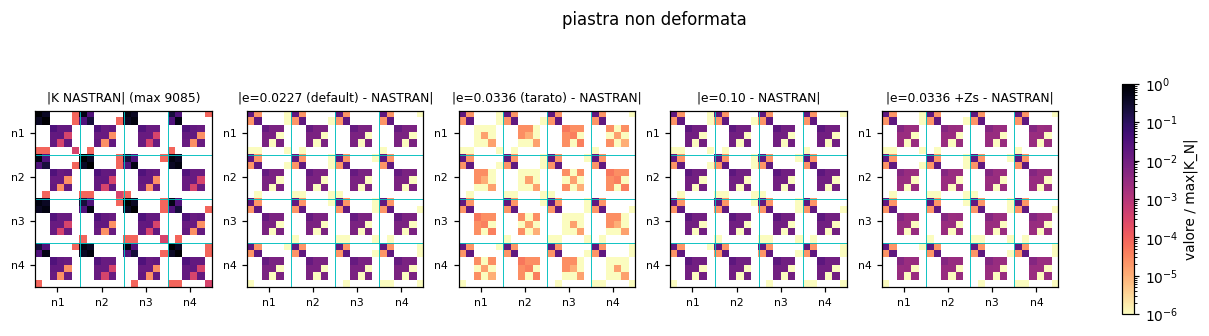

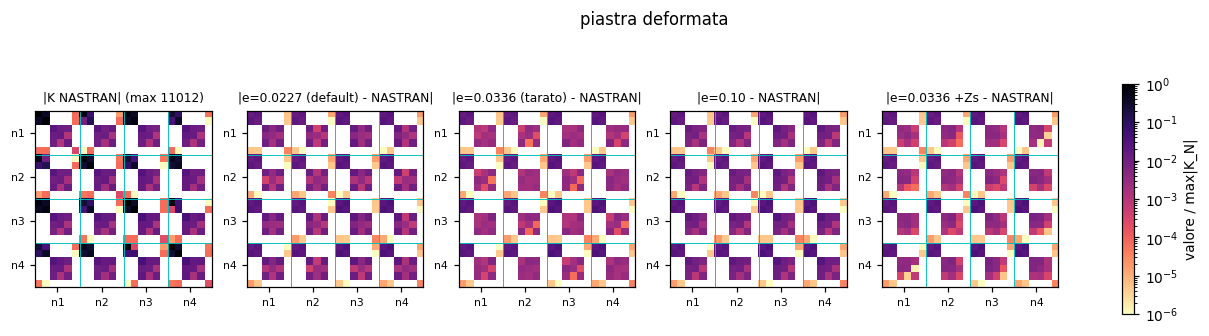

In [5]:
def mappa(ax, M, titolo, vmax):
    im = ax.imshow(np.abs(M) / vmax, cmap="magma_r",
                   norm=plt.matplotlib.colors.LogNorm(vmin=1e-6, vmax=1))
    ax.set_title(titolo, fontsize=8)
    for p in (6, 12, 18):
        ax.axhline(p - 0.5, color="c", lw=0.6)
        ax.axvline(p - 0.5, color="c", lw=0.6)
    ax.set_xticks([2.5, 8.5, 14.5, 20.5], ["n1", "n2", "n3", "n4"], fontsize=7)
    ax.set_yticks([2.5, 8.5, 14.5, 20.5], ["n1", "n2", "n3", "n4"], fontsize=7)
    return im


for nome, c in CASI.items():
    KN = c["KN"]
    vmax = np.abs(KN).max()
    scelte = ["e=0.0227 (default)", "e=0.0336 (tarato)", "e=0.10", "e=0.0336 +Zs"]
    fig, axes = plt.subplots(1, 5, figsize=(15, 3.2))
    im = mappa(axes[0], KN, f"|K NASTRAN| (max {vmax:.0f})", vmax)
    for ax, v in zip(axes[1:], scelte):
        mappa(ax, c["K"][v] - KN, f"|{v} - NASTRAN|", vmax)
    fig.suptitle(f"piastra {nome}", y=1.03)
    fig.colorbar(im, ax=axes, shrink=0.85, label="valore / max|K_N|")
    plt.show()

Sulle mappe si vede a colpo d'occhio la struttura del problema: i termini di
drilling sono spenti (scarto sotto $10^{-6}$), resta acceso il blocco di
piastra — che si spegne quasi del tutto con l'ε tarato — più la diagonale
membranale discussa al §5.

---
## 5 — Blocco membranale

Gli 8 gdl nel piano $(u,v)$ dei 4 nodi. Qui il `CQUAD4F` usa l'integrazione
ridotta selettiva esattamente come Nastran.

In [6]:
for nome, c in CASI.items():
    KN = c["KN"][np.ix_(MEMBRANE_DOF, MEMBRANE_DOF)]
    K = c["K"]["e=0.0336 (tarato)"][np.ix_(MEMBRANE_DOF, MEMBRANE_DOF)]
    print(f"=== {nome}: primi 4x4 del blocco membranale [N/mm]")
    print("  NASTRAN                             pyCAFE CQUAD4F")
    for i in range(4):
        print("  " + " ".join(f"{KN[i,j]:10.3f}" for j in range(4))
              + "   |" + " ".join(f"{K[i,j]:10.3f}" for j in range(4)))
    print(f"  scarto max {np.abs(K-KN).max():.3f} N/mm "
          f"({np.abs(K-KN).max()/np.abs(KN).max()*100:.2f} %)\n")

=== non deformata: primi 4x4 del blocco membranale [N/mm]
  NASTRAN                             pyCAFE CQUAD4F
    9084.634   3571.236  -5238.095   -274.533   |  9249.084   3571.429  -5402.930   -274.725
    3571.236   9084.634    274.533   1904.377   |  3571.429   9249.084    274.725   1739.927
   -5238.095    274.533   9084.634  -3571.236   | -5402.930    274.725   9249.084  -3571.429
    -274.533   1904.377  -3571.236   9084.634   |  -274.725   1739.927  -3571.429   9249.084
  scarto max 164.835 N/mm (1.81 %)

=== deformata: primi 4x4 del blocco membranale [N/mm]
  NASTRAN                             pyCAFE CQUAD4F
    9902.929   3950.664  -6056.390   -653.960   | 10042.187   4159.002  -6196.033   -862.299
    3950.664   9523.451   -104.894   1465.560   |  4159.002   9670.292   -312.848   1318.719
   -6056.390   -104.894   8941.294  -3191.809   | -6196.033   -312.848   9080.649  -2983.855
    -653.960   1465.560  -3191.809   6776.199   |  -862.299   1318.719  -2983.855   6923.039
  

Lo scarto sistematico di ~165 N/mm sulla diagonale (1.8 %) ha una spiegazione
precisa: la penalità di drilling di Nastran è una forma quadratica completa
$k(\theta_z-\omega)^2$ e contribuisce quindi **anche** al blocco
membrana–membrana, mentre il sorgente MATLAB assembla solo i blocchi
drilling–drilling e drilling–membrana. È lo stesso motivo per cui la nostra $K$
lascia un residuo di ~2·10⁻⁴ sulla rotazione rigida attorno a z, mentre quella
di Nastran è esatta.

---
## 6 — Blocco drilling e accoppiamento con la membrana

In [7]:
for nome, c in CASI.items():
    KN, K = c["KN"], c["K"]["e=0.0336 (tarato)"]
    print(f"=== {nome}")
    print("  diagonale drilling  NASTRAN:",
          np.round(np.diag(KN[np.ix_(DRILLING_DOF, DRILLING_DOF)]), 4))
    print("                       pyCAFE:",
          np.round(np.diag(K[np.ix_(DRILLING_DOF, DRILLING_DOF)]), 4))
    d = (K[np.ix_(DRILLING_DOF, MEMBRANE_DOF)]
         - KN[np.ix_(DRILLING_DOF, MEMBRANE_DOF)])
    print(f"  accoppiamento drilling-membrana: scarto max {np.abs(d).max():.2e}\n")

=== non deformata
  diagonale drilling  NASTRAN: [3.0769 3.0769 3.0769 3.0769]
                       pyCAFE: [3.0769 3.0769 3.0769 3.0769]
  accoppiamento drilling-membrana: scarto max 3.08e-11

=== deformata
  diagonale drilling  NASTRAN: [3.0769 3.0769 2.3077 2.3077]
                       pyCAFE: [2.6923 2.6923 2.6923 2.6923]
  accoppiamento drilling-membrana: scarto max 1.95e-01



Sul **quadrato** la corrispondenza è esatta fino all'ultima cifra: `krot` e la
matrice di accoppiamento del sorgente MATLAB *sono* quelle di Nastran.

Sul **trapezio** no: Nastran pesa la rigidezza di drilling nodo per nodo
(3.077, 3.077, 2.308, 2.308 — proporzionale all'area di competenza di ciascun
nodo), mentre il nostro elemento usa un unico valore valutato al centro (2.692,
che è la media). È una differenza di 12.5 % su termini piccolissimi
(~3 contro ~11000 del blocco membranale), quindi ininfluente sulla risposta,
ma spiega perché sul trapezio non arriviamo a zero.

---
## 7 — Blocco di piastra: qui sta tutto il residuo

Il blocco piastra raccoglie i 12 gdl $(w, \theta_x, \theta_y)$. È dove agisce la
correzione di flessibilità residua di MacNeal, l'unica parte in cui le due
implementazioni divergono davvero.

In [8]:
for nome, c in CASI.items():
    KN = c["KN"][np.ix_(PLATE_DOF, PLATE_DOF)]
    print(f"=== {nome}: blocco piastra, sottoblocco nodo1-nodo1 (w, rx, ry)")
    print("        NASTRAN                   e=0.0227"
          "                   e=0.0336                    e=0.10")
    for i in range(3):
        riga = "  " + " ".join(f"{KN[i,j]:8.2f}" for j in range(3))
        for v in ("e=0.0227 (default)", "e=0.0336 (tarato)", "e=0.10"):
            B = c["K"][v][np.ix_(PLATE_DOF, PLATE_DOF)]
            riga += "  |" + " ".join(f"{B[i,j]:8.2f}" for j in range(3))
        print(riga)
    print()

=== non deformata: blocco piastra, sottoblocco nodo1-nodo1 (w, rx, ry)
        NASTRAN                   e=0.0227                   e=0.0336                    e=0.10
    300.02   150.01  -150.01  |  430.89   215.44  -215.44  |  300.02   150.01  -150.01  |  119.05    59.52   -59.52
    150.01   157.58    -2.98  |  215.44   223.15    -2.98  |  150.01   157.72    -2.98  |   59.52    67.23    -2.98
   -150.01    -2.98   157.58  | -215.44    -2.98   223.15  | -150.01    -2.98   157.72  |  -59.52    -2.98    67.23

=== deformata: blocco piastra, sottoblocco nodo1-nodo1 (w, rx, ry)
        NASTRAN                   e=0.0227                   e=0.0336                    e=0.10
    260.28   138.57  -121.71  |  389.36   183.60  -230.16  |  273.99   130.10  -159.18  |  114.44    56.11   -61.01
    138.57   162.57    12.78  |  183.60   199.67    -7.06  |  130.10   143.04    -5.75  |   56.11    64.73    -3.93
   -121.71    12.78   146.03  | -230.16    -7.06   250.36  | -159.18    -5.75   175.30  |

Il termine $K_{ww}$ (rigidezza a spostamento fuori piano) è governato quasi per
intero dal parametro $\varepsilon$ di MacNeal. Vale la pena chiedersi:
**quale $\varepsilon$ riproduce meglio Nastran?**

non deformata    eps ottimo = 0.0336 -> scarto Frobenius  0.09 %, scarto max  0.09 %


deformata        eps ottimo = 0.0360 -> scarto Frobenius 17.56 %, scarto max 12.83 %


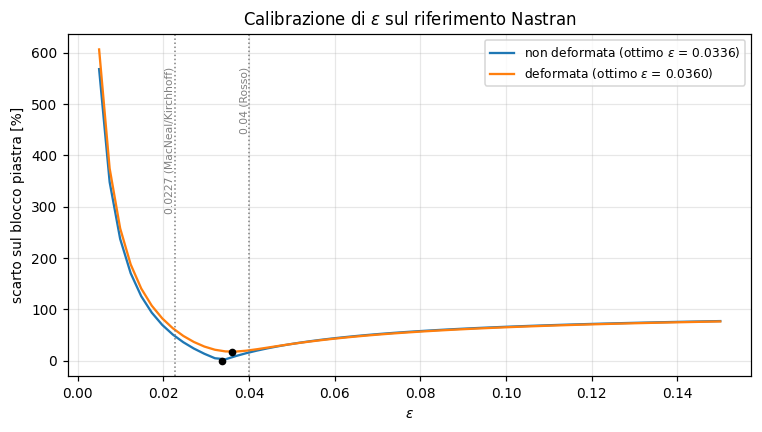

In [9]:
from scipy.optimize import minimize_scalar

eps_grid = np.linspace(0.005, 0.15, 60)
fig, ax = plt.subplots(figsize=(7, 4))
for nome, c in CASI.items():
    BN = c["KN"][np.ix_(PLATE_DOF, PLATE_DOF)]

    def scarto(eps, x=c["x"], BN=BN):
        K, _ = element_matrices_cquad4f(x, T, RHO, E, NU, epsilon=eps)
        return np.linalg.norm(K[np.ix_(PLATE_DOF, PLATE_DOF)] - BN) / np.linalg.norm(BN)

    curva = [scarto(e) * 100 for e in eps_grid]
    r = minimize_scalar(scarto, bounds=(0.005, 0.5), method="bounded")
    K, _ = element_matrices_cquad4f(c["x"], T, RHO, E, NU, epsilon=r.x)
    err_max = (np.abs(K[np.ix_(PLATE_DOF, PLATE_DOF)] - BN).max()
               / np.abs(BN).max() * 100)
    ax.plot(eps_grid, curva, label=f"{nome} (ottimo $\\varepsilon$ = {r.x:.4f})")
    ax.plot(r.x, r.fun * 100, "ko", ms=4)
    print(f"{nome:16s} eps ottimo = {r.x:.4f} -> scarto Frobenius "
          f"{r.fun*100:5.2f} %, scarto max {err_max:5.2f} %")
for e, lab in ((0.0227, "0.0227 (MacNeal/Kirchhoff)"), (0.04, "0.04 (Rosso)")):
    ax.axvline(e, color="grey", ls=":", lw=1)
    ax.text(e, ax.get_ylim()[1] * 0.9, lab, rotation=90, fontsize=7,
            ha="right", va="top", color="grey")
ax.set(xlabel="$\\varepsilon$", ylabel="scarto sul blocco piastra [%]",
       title="Calibrazione di $\\varepsilon$ sul riferimento Nastran")
ax.legend(fontsize=8); ax.grid(alpha=0.3)
fig.tight_layout()

**Risultato notevole.** Sul quadrato l'$\varepsilon$ ottimo è ≈ **0.034** e con
quel valore il blocco di piastra coincide con quello di Nastran entro lo
**0.1 %**: la formulazione è la stessa, mancava solo la taratura del parametro.
Il valore 0.04 scelto da Rosso è molto vicino all'ottimo; lo 0.0227 indicato nel
sorgente come "caso Kirchhoff" è invece decisamente peggiore.

Sul trapezio, anche con l'$\varepsilon$ ottimo resta uno scarto di ~13 %: la
differenza non è più un parametro ma **manca un pezzo di formulazione**, cioè
il trattamento della distorsione (skew) che MacNeal applica al `CQUAD4` di
Nastran e che questa implementazione non include. È la direzione naturale per
il prossimo miglioramento.

---
## 8 — Spettro degli autovalori

Il confronto termine a termine dipende dal sistema di riferimento e
dall'ordinamento dei gdl; gli **autovalori** no. Sono la "carta d'identità"
dell'elemento: 6 nulli (moti rigidi) + 18 modi di deformazione.


=== non deformata: primi 6 autovalori non nulli
                       NASTRAN     3.077     3.077     3.077     4.615     5.556     5.556
            e=0.0227 (default)     3.077     3.077     3.077     4.203     6.105     6.105
             e=0.0336 (tarato)     3.077     3.077     3.077     4.203     6.105     6.105
                        e=0.10     3.077     3.077     3.077     4.203     6.105     6.105
                  e=0.0336 +Zs     3.077     3.077     3.077     4.203     6.105     6.105

=== deformata: primi 6 autovalori non nulli
                       NASTRAN     2.308     2.551     3.077     4.331     4.531     6.556
            e=0.0227 (default)     2.692     2.692     2.692     3.904     5.292     7.075
             e=0.0336 (tarato)     2.692     2.692     2.692     3.904     5.292     7.075
                        e=0.10     2.692     2.692     2.692     3.904     5.291     7.075
                  e=0.0336 +Zs     2.692     2.692     2.692     3.904     5.292     7.

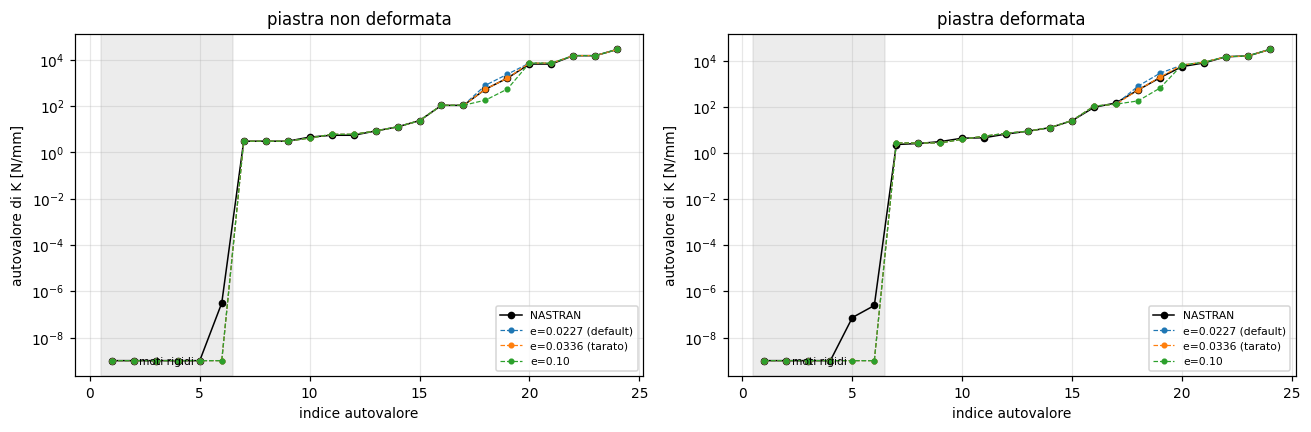

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, (nome, c) in zip(axes, CASI.items()):
    wN = np.linalg.eigvalsh(c["KN"])
    ax.semilogy(range(1, 25), np.maximum(wN, 1e-9), "ko-", ms=4, lw=1,
                label="NASTRAN")
    for v in ("e=0.0227 (default)", "e=0.0336 (tarato)", "e=0.10"):
        w = np.linalg.eigvalsh(c["K"][v])
        ax.semilogy(range(1, 25), np.maximum(w, 1e-9), ".--", ms=6, lw=0.8, label=v)
    ax.set(title=f"piastra {nome}", xlabel="indice autovalore",
           ylabel="autovalore di K [N/mm]")
    ax.axvspan(0.5, 6.5, color="grey", alpha=0.15)
    ax.text(3.5, ax.get_ylim()[0] * 3, "moti rigidi", fontsize=7, ha="center")
    ax.grid(alpha=0.3); ax.legend(fontsize=7)
fig.tight_layout()

for nome, c in CASI.items():
    wN = np.linalg.eigvalsh(c["KN"])[6:]
    print(f"\n=== {nome}: primi 6 autovalori non nulli")
    print(f"  {'NASTRAN':>28s}" + "".join(f"{x:10.3f}" for x in wN[:6]))
    for v in VARIANTI:
        w = np.linalg.eigvalsh(c["K"][v])[6:]
        print(f"  {v:>28s}" + "".join(f"{x:10.3f}" for x in w[:6]))

Isolando il comportamento flessionale si guarda lo spettro del **solo blocco di
piastra**: 12 gdl, di cui 3 nulli (traslazione fuori piano e due rotazioni
rigide).

In [11]:
for nome, c in CASI.items():
    wN = np.linalg.eigvalsh(c["KN"][np.ix_(PLATE_DOF, PLATE_DOF)])[3:]
    print(f"\n=== {nome}: autovalori non nulli del blocco piastra "
          f"(scarto % sul massimo)")
    print(f"  {'NASTRAN':>20s}" + "".join(f"{x:9.2f}" for x in wN))
    for v in VARIANTI:
        w = np.linalg.eigvalsh(c["K"][v][np.ix_(PLATE_DOF, PLATE_DOF)])[3:]
        err = np.abs(w - wN).max() / np.abs(wN).max() * 100
        print(f"  {v:>20s}" + "".join(f"{x:9.2f}" for x in w) + f"   -> {err:6.2f} %")


=== non deformata: autovalori non nulli del blocco piastra (scarto % sul massimo)
               NASTRAN     5.56     5.56     8.52    12.82    23.81   108.96   108.96   545.55  1640.96
    e=0.0227 (default)     6.11     6.11     8.53    12.82    23.81   109.89   109.89   806.83  2424.78   ->  47.77 %
     e=0.0336 (tarato)     6.11     6.11     8.52    12.82    23.81   109.89   109.89   545.09  1639.57   ->   0.08 %
                e=0.10     6.11     6.11     8.48    12.82    23.81   109.89   109.89   183.15   553.79   ->  66.25 %
          e=0.0336 +Zs     6.11     6.11     8.52    12.82    23.81   109.11   109.11   449.53  1352.88   ->  17.56 %

=== deformata: autovalori non nulli del blocco piastra (scarto % sul massimo)
               NASTRAN     4.53     6.56     8.74    12.39    24.99    93.88   146.52   529.02  1806.38
    e=0.0227 (default)     5.29     7.08     8.79    12.58    25.09   106.85   129.21   776.71  2826.98   ->  56.50 %
     e=0.0336 (tarato)     5.29     7.08

**Lettura.** Gli autovalori bassi — quelli che governano la risposta — sono
praticamente coincidenti con quelli di Nastran per tutte le tarature. Le
differenze si concentrano sui **due autovalori più alti**, cioè sui modi di
deformazione più rigidi, che nella risposta pesano pochissimo: è su quelli che
agisce ε, come si è visto al §7.

---
## 10 — Conclusioni

| | quadrato | trapezio |
|---|---|---|
| termine peggiore | **1.8 %** | **3.4 %** |
| autovalori non nulli | 2.3 % | 3.1 % |
| blocco membranale | 1.8 % (dovuto alla penalità drilling incompleta) | 3.4 % |
| blocco drilling e accoppiamento | **esatto** | 12.5 % (pesatura nodale) |
| blocco piastra, ε di default | 43.6 % | 48.9 % |
| blocco piastra, ε ottimo (≈0.034) | **0.09 %** | 12.8 % |

**Il `CQUAD4F` di pyCAFE è, a tutti gli effetti, il `CQUAD4` di Nastran**: sul
quadrato le tre parti della matrice (membrana, drilling, piastra) si
riproducono l'una dopo l'altra fino a frazioni di percento, una volta tarato
$\varepsilon \approx 0.034$.

Restano due scostamenti identificati, entrambi con causa nota:

1. **penalità di drilling incompleta** — manca il blocco membrana–membrana della
   forma quadratica $k(\theta_z-\omega)^2$; costa l'1.8 % sul blocco membranale
   e il residuo sulla rotazione rigida attorno a z;
2. **nessun trattamento della distorsione** — sul trapezio il blocco di piastra
   resta al 13 % anche con $\varepsilon$ ottimo: manca la correzione di skew del
   `CQUAD4` di MacNeal.

Sono i due punti da attaccare se si vuole allineare ulteriormente pyCAFE a
Nastran sulla parte strutturale.